[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv12 Object Detection on a Custom Dataset

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolov12-object-detection-model.ipynb)
[![arXiv](https://img.shields.io/badge/arXiv-2502.12524-b31b1b.svg)](https://arxiv.org/abs/2502.12524)
[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/train-yolov12-model)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/sunsmarterjie/yolov12)

[YOLOv12](https://github.com/sunsmarterjie/yolov12) is a newly proposed attention-centric variant of the YOLO family that focuses on incorporating efficient attention mechanisms into the backbone while preserving real-time performance. Instead of relying heavily on CNN-based architectures like its predecessors, YOLOv12 introduces a simple yet powerful “area attention” module, which strategically partitions the feature map to reduce the quadratic complexity of full self-attention. It also adopts residual efficient layer aggregation networks (R-ELAN) to enhance feature aggregation and training stability, especially for larger models. These innovations, together with refinements such as scaled residual connections and a reduced MLP ratio, enable YOLOv12 to harness the benefits of attention (e.g., better global context modeling) without sacrificing speed.

![yolov12-area-attention](https://media.roboflow.com/notebooks/examples/yolov12-area-attention.png)

Compared to prior YOLO iterations (e.g., YOLOv10, YOLOv11, and YOLOv8), YOLOv12 achieves higher detection accuracy with competitive or faster inference times across all model scales. Its five sizes—N, S, M, L, and X—range from 2.6M to 59.1M parameters, striking a strong accuracy–speed balance. For instance, the smallest YOLOv12-N surpasses other “nano” models by over 1% mAP with latency around 1.6 ms on a T4 GPU, and the largest YOLOv12-X achieves 55.2% mAP, comfortably outscoring comparable real-time detectors such as RT-DETR and YOLOv11-X . By matching or exceeding state-of-the-art accuracy while remaining fast, YOLOv12 represents a notable step forward for attention-based real-time object detection.

![yolov12-metrics](https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov12-metrics.png)

## Environment setup

### Configure your API keys

To fine-tune YOLOv12, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [2]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [3]:
import os
from google.colab import userdata
from roboflow import Roboflow

# 從 Secret 中安全讀取金鑰
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])
project = rf.workspace("你的_workspace_name").project("你的_project_name")
dataset = project.version(1).download("yolov11")


RuntimeError: {
    "error": {
        "message": "This API key does not exist (or has been revoked).",
        "status": 401,
        "type": "OAuthException",
        "hint": "You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours.",
        "key": "rf_UPh4Htzhj8aL4EzEe9xIgXi89T52"
    }
}

In [4]:
from roboflow import Roboflow

rf = Roboflow(api_key="G4Did6joLQEJ5npDriR9")

project = rf.workspace("caroline-rhh2u").project("-rznc2")
dataset = project.version(1).download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


### Check GPU availability

**NOTE:** **YOLOv12 leverages FlashAttention to speed up attention-based computations, but this feature requires an Nvidia GPU built on the Ampere architecture or newer—for example, GPUs like the RTX 3090, RTX 3080, or even the Nvidia L4 meet this requirement.**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [5]:
!nvidia-smi

Wed Oct 29 05:02:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies

**NOTE:** Currently, YOLOv12 does not have its own PyPI package, so we install it directly from GitHub while also adding roboflow (to conveniently pull datasets from the Roboflow Universe), supervision (to visualize inference results and benchmark the model’s performance), and flash-attn (to accelerate attention-based computations via optimized CUDA kernels).

In [7]:
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git roboflow supervision flash-attn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 85.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 21.5 MB/s eta 0:00:00


### Download example data

Let's download an image we can use for YOLOv12 inference. Feel free to drag and drop your own images into the Files tab on the left-hand side of Google Colab, then reference their filenames in your code for a custom inference demo.

In [1]:
!wget https://media.roboflow.com/notebooks/examples/dog.jpeg

--2025-10-29 05:04:27--  https://media.roboflow.com/notebooks/examples/dog.jpeg
Resolving media.roboflow.com (media.roboflow.com)... 34.110.133.209
Connecting to media.roboflow.com (media.roboflow.com)|34.110.133.209|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106055 (104K) [image/jpeg]
Saving to: ‘dog.jpeg’

dog.jpeg            100%[===================>] 103.57K  --.-KB/s    in 0.001s  

2025-10-29 05:04:27 (151 MB/s) - ‘dog.jpeg’ saved [106055/106055]



## Run inference

In the example, we're using the `yolov12l.pt` model, but you can experiment with different model sizes by simply swapping out the model name during initialization. Options include `yolov12n.pt`, `yolov12s.pt`, `yolov12m.pt`, `yolov12l.pt`, and `yolov12x.pt`.

In [14]:
import cv2
from ultralytics import YOLO
import supervision as sv


image_path = f"{HOME}/dog.jpeg"
image = cv2.imread(image_path)

model = YOLO('yolov12l.pt')

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.


AttributeError: 'NoneType' object has no attribute 'copy'

In [10]:
import os
import cv2
from ultralytics import YOLO
import supervision as sv

HOME = os.path.expanduser("~")

image_path = f"{HOME}/dog.jpeg"
image = cv2.imread(image_path)

model = YOLO('yolov12l.pt')

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)


100%|██████████| 51.4M/51.4M [00:00<00:00, 304MB/s]


WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.


AttributeError: 'NoneType' object has no attribute 'copy'

In [12]:
from google.colab import files
import os
import cv2
from ultralytics import YOLO
import supervision as sv

uploaded = files.upload()

image_path = "/content/dog.jpeg"
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"⚠️ 找不到圖片：{image_path}，請確認檔案已上傳")

model = YOLO('yolov12l.pt')

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)


KeyboardInterrupt: 

使用圖片：/content/圖-1/valid/images/IMG_20181228_103424_jpeg.rf.e6ac949b0201ee5d3b96ccc08bbd8bb7.jpg


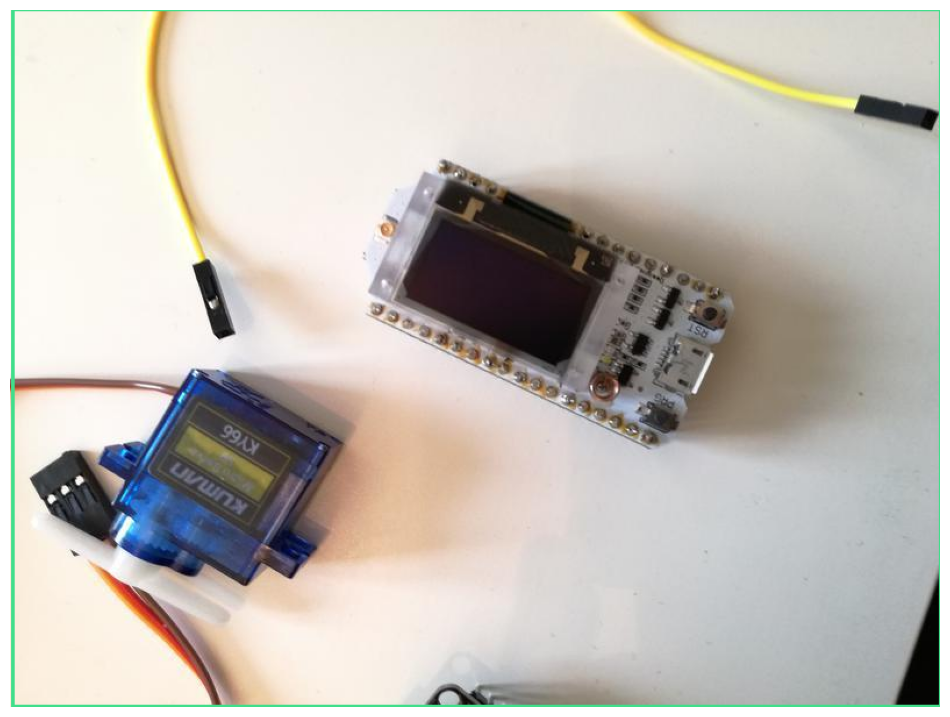

In [15]:
import glob
import cv2
from ultralytics import YOLO
import supervision as sv
import os

dataset_path = dataset.location

valid_images = glob.glob(os.path.join(dataset_path, "valid/images", "*.jpg")) + \
               glob.glob(os.path.join(dataset_path, "valid/images", "*.jpeg")) + \
               glob.glob(os.path.join(dataset_path, "valid/images", "*.png"))

if not valid_images:
    raise FileNotFoundError("找不到驗證集圖片，請確認路徑是否正確。")

image_path = valid_images[0]
print(f"使用圖片：{image_path}")

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"無法讀取圖片：{image_path}")

model = YOLO("yolov12l.pt")

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)




```
# 此內容會顯示為程式碼
```

## Download dataset from Roboflow Universe

In [34]:
from roboflow import download_dataset

dataset = download_dataset('https://universe.roboflow.com/roboflow-100/circuit-voltages/dataset/2', 'yolov8')

RuntimeError: {
    "error": {
        "message": "This API key does not exist (or has been revoked).",
        "status": 401,
        "type": "OAuthException",
        "hint": "You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours.",
        "key": "rf_UPh4Htzhj8aL4EzEe9xIgXi89T52"
    }
}

In [36]:
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow()

dataset = rf.load_dataset_from_url(
    "https://universe.roboflow.com/roboflow-100/circuit-voltages/dataset/2",
    model_format="yolov11"
)

print("資料集下載完成！")
print("資料集儲存位置：", dataset.location)


RuntimeError: {
    "error": {
        "message": "This API key does not exist (or has been revoked).",
        "status": 401,
        "type": "OAuthException",
        "hint": "You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours.",
        "key": "rf_UPh4Htzhj8aL4EzEe9xIgXi89T52"
    }
}

In [37]:

!pip uninstall -y roboflow
!pip install roboflow -q

import os

if "ROBOFLOW_API_KEY" in os.environ:
    del os.environ["ROBOFLOW_API_KEY"]

from roboflow import Roboflow

rf = Roboflow(api_key=None)

dataset = rf.load_dataset_from_url(
    "https://universe.roboflow.com/roboflow-100/circuit-voltages/dataset/2",
    model_format="yolov11"
)

print("資料集下載完成！")
print("儲存位置：", dataset.location)


Found existing installation: roboflow 1.2.11
Uninstalling roboflow-1.2.11:
  Successfully uninstalled roboflow-1.2.11


RuntimeError: API Key is of Incorrect Type 
 Expected Type: <class 'str'>
 Input Type: <class 'NoneType'>

In [38]:
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="rf_UPh4Htzhj8aL4EzEe9xIgXi89T52")

dataset = rf.load_dataset_from_url(
    "https://universe.roboflow.com/roboflow-100/circuit-voltages/dataset/2",
    model_format="yolov11"
)

print("資料集下載完成！")
print("儲存位置：", dataset.location)


RuntimeError: {
    "error": {
        "message": "This API key does not exist (or has been revoked).",
        "status": 401,
        "type": "OAuthException",
        "hint": "You may retrieve your API key via the Roboflow Dashboard. Go to Account > Roboflow Keys to retrieve yours.",
        "key": "rf_UPh4Htzhj8aL4EzEe9xIgXi89T52"
    }
}

In [42]:
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="G4Did6joLQEJ5npDriR9")

dataset = rf.load_dataset_from_url(
    "https://universe.roboflow.com/roboflow-100/circuit-voltages/dataset/2",
    model_format="yolov11"
)

print("資料集下載完成！")
print("儲存位置：", dataset.location)


AttributeError: 'Roboflow' object has no attribute 'load_dataset_from_url'

In [47]:
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="G4Did6joLQEJ5npDriR9")

project = rf.workspace("caroline-rhh2u").project("-rznc2")

dataset = project.version(2).download("yolov11")

print("資料集下載完成！")
print("儲存位置：", dataset.location)


loading Roboflow workspace...
loading Roboflow project...


RuntimeError: Version number 2 is not found.

In [5]:
from roboflow import Roboflow

rf = Roboflow(api_key="G4Did6joLQEJ5npDriR9")
project = rf.workspace("caroline-rhh2u").project("-rznc2")

print("專案版本列表：")
for v in project.versions():
    print(f"Version {v.version} - {v.name}")


loading Roboflow workspace...
loading Roboflow project...
專案版本列表：
Version 1 - 圖


In [6]:
dataset = project.version(1).download("yolov11")


In [7]:
!ls {dataset.location}

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


**NOTE:** We need to make a few changes to our downloaded dataset so it will work with YOLOv12. Run the following bash commands to prepare your dataset for training by updating the relative paths in the `data.yaml` file, ensuring it correctly points to the subdirectories for your dataset's `train`, `test`, and `valid` subsets.

In [8]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [9]:
!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['Arduino_Nano', 'ESP8266', 'Heltec_ESP32_Lora', 'NodeMCU', 'Raspberry_Pi_3']

roboflow:
  workspace: caroline-rhh2u
test: ../test/images
train: ../train/images
val: ../valid/images


## Fine-tune YOLOv12 model

We are now ready to fine-tune our YOLOv12 model. In the code below, we initialize the model using a starting checkpoint—here, we use `yolov12s.yaml`, but you can replace it with any other model (e.g., `yolov12n.pt`, `yolov12m.pt`, `yolov12l.pt`, or `yolov12x.pt`) based on your preference. We set the training to run for 100 epochs in this example; however, you should adjust the number of epochs along with other hyperparameters such as batch size, image size, and augmentation settings (scale, mosaic, mixup, and copy-paste) based on your hardware capabilities and dataset size.

**Note:** **Note that after training, you might encounter a `TypeError: argument of type 'PosixPath' is not iterable error` — this is a known issue, but your model weights will still be saved, so you can safely proceed to running inference.**

In [52]:
from ultralytics import YOLO

model = YOLO('yolov12s.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/content/圖-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

train: Scanning /content/圖-1/train/labels... 78 images, 12 backgrounds, 0 corrupt: 100%|██████████| 78/78 [00:00<00:00, 501.04it/s]

train: New cache created: /content/圖-1/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/圖-1/valid/labels... 40 images, 0 backgrounds, 0 corrupt: 100%|██████████| 40/40 [00:00<00:00, 314.17it/s]

val: New cache created: /content/圖-1/valid/labels.cache


...

    100/100      6.66G      1.571      2.221       2.39         11        640: 100%|██████████| 5/5 [00:02<00:00,  1.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.80it/s]

                   all         40         52        0.6      0.265      0.305      0.117



100 epochs completed in 0.118 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 18.6MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 18.6MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,076,143 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.87it/s]


                   all         40         52       0.61      0.331      0.327      0.123
          Arduino_Nano         12         12          1      0.409       0.47       0.18
               ESP8266         13         14          0          0     0.0454      0.019
     Heltec_ESP32_Lora         14         14          1          0     0.0701      0.021
        Raspberry_Pi_3         12         12      0.439      0.917      0.722      0.273
Speed: 0.2ms preprocess, 7.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/train4


In [53]:
from ultralytics import YOLO

dataset_path = f'{dataset.location}/data.yaml'

train_params = {
    "data": dataset_path,
    "epochs": 200,
    "batch": 16,
    "imgsz": 640,
    "lr0": 0.01,
    "augment": True,
    "optimizer": "SGD",
    "verbose": True,
    "workers": 4,
    "project": "runs/train_improved",
    "name": "yolov12s_aug",
    "exist_ok": True
}

model = YOLO('yolov12s.yaml')
results = model.train(**train_params)

mAP50_95 = results.metrics.box.map50_95

def score_map(mAP):
    if mAP >= 0.90:
        return 100
    elif mAP >= 0.85:
        return 80
    else:
        return 0

score = score_map(mAP50_95)

print(f"驗證集 mAP50-95: {mAP50_95:.4f}")
print(f"依照規則，得分為: {score} 分")


New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/content/圖-1/data.yaml, epochs=200, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=runs/train_improved, name=yolov12s_aug, exist_ok=True, pretrained=True, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show

train: Scanning /content/圖-1/train/labels.cache... 78 images, 12 backgrounds, 0 corrupt: 100%|██████████| 78/78 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/圖-1/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|██████████| 40/40 [00:00<?, ?it/s]


Plotting labels to runs/train_improved/yolov12s_aug/labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/train_improved/yolov12s_aug
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         40         52      0.416      0.248      0.341      0.146



200 epochs completed in 0.215 hours.
Optimizer stripped from runs/train_improved/yolov12s_aug/weights/last.pt, 18.6MB
Optimizer stripped from runs/train_improved/yolov12s_aug/weights/best.pt, 18.6MB

Validating runs/train_improved/yolov12s_aug/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,076,143 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:15<00:00,  7.96s/it]


                   all         40         52      0.346      0.305      0.348      0.156
          Arduino_Nano         12         12      0.668      0.333      0.526      0.255
               ESP8266         13         14     0.0466     0.0466     0.0342     0.0132
     Heltec_ESP32_Lora         14         14          0          0          0          0
        Raspberry_Pi_3         12         12      0.668       0.84      0.833      0.355
Speed: 0.2ms preprocess, 393.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/train_improved/yolov12s_aug


AttributeError: 'DetMetrics' object has no attribute 'metrics'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and data when

In [54]:
from ultralytics import YOLO

model = YOLO('yolov12s.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

metrics = results.metrics
mAP50_95 = metrics.maps.get("0.5:0.95", None)

if mAP50_95 is None:
    print("找不到 mAP50-95 指標")
else:
    def score_map(mAP):
        if mAP >= 0.90:
            return 100
        elif mAP >= 0.85:
            return 80
        else:
            return 0

    score = score_map(mAP50_95)
    print(f"驗證集 mAP50-95: {mAP50_95:.4f}")
    print(f"依照規則，得分為: {score} 分")


New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12s.yaml, data=/content/圖-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frame

train: Scanning /content/圖-1/train/labels.cache... 78 images, 12 backgrounds, 0 corrupt: 100%|██████████| 78/78 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/圖-1/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|██████████| 40/40 [00:00<?, ?it/s]


Plotting labels to runs/detect/train5/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 121 weight(decay=0.0), 128 weight(decay=0.0005), 127 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train5
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all         40         52        0.6      0.265      0.305      0.117



100 epochs completed in 0.115 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 18.6MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 18.6MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12s summary (fused): 376 layers, 9,076,143 parameters, 0 gradients, 19.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.79it/s]


                   all         40         52       0.61      0.331      0.327      0.123
          Arduino_Nano         12         12          1      0.409       0.47       0.18
               ESP8266         13         14          0          0     0.0454      0.019
     Heltec_ESP32_Lora         14         14          1          0     0.0701      0.021
        Raspberry_Pi_3         12         12      0.439      0.917      0.722      0.273
Speed: 0.2ms preprocess, 7.5ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/train5


AttributeError: 'DetMetrics' object has no attribute 'metrics'. See valid attributes below.

    Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP) of an
    object detection model.

    Args:
        save_dir (Path): A path to the directory where the output plots will be saved. Defaults to current directory.
        plot (bool): A flag that indicates whether to plot precision-recall curves for each class. Defaults to False.
        on_plot (func): An optional callback to pass plots path and data when they are rendered. Defaults to None.
        names (dict of str): A dict of strings that represents the names of the classes. Defaults to an empty tuple.

    Attributes:
        save_dir (Path): A path to the directory where the output plots will be saved.
        plot (bool): A flag that indicates whether to plot the precision-recall curves for each class.
        on_plot (func): An optional callback to pass plots path and data when

In [1]:
from ultralytics import YOLO

model = YOLO('yolov12s.yaml')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

mAP50_95 = results.maps.get("0.5:0.95", None)

if mAP50_95 is None:
    print("找不到 mAP50-95 指標")
else:
    def score_map(mAP):
        if mAP >= 0.90:
            return 100
        elif mAP >= 0.85:
            return 80
        else:
            return 0

    score = score_map(mAP50_95)
    print(f"驗證集 mAP50-95: {mAP50_95:.4f}")
    print(f"依照規則，得分為: {score} 分")


FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


NameError: name 'dataset' is not defined

In [ ]:
results = model.train(data=f'{dataset.location}/data.yaml', epochs=100)

mAP50_95 = results.maps[1]

def score_map(mAP):
    if mAP >= 0.90:
        return 100
    elif mAP >= 0.85:
        return 80
    else:
        return 0

score = score_map(mAP50_95)
print(f"驗證集 mAP50-95: {mAP50_95:.4f}")
print(f"依照規則，得分為: {score} 分")


New https://pypi.org/project/ultralytics/8.3.221 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov12l.pt, data=/content/圖-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=Fals

100%|██████████| 755k/755k [00:00<00:00, 10.9MB/s]


Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2, 1, 2]         
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    147968  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2, 1, 4]        
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  4   4540416  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 4, True, 1.5]
  7                  -1  1   2360320  ultralyt

train: Scanning /content/圖-1/train/labels... 78 images, 12 backgrounds, 0 corrupt: 100%|██████████| 78/78 [00:00<00:00, 2313.05it/s]

train: New cache created: /content/圖-1/train/labels.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/圖-1/valid/labels... 40 images, 0 backgrounds, 0 corrupt: 100%|██████████| 40/40 [00:00<00:00, 1985.75it/s]

val: New cache created: /content/圖-1/valid/labels.cache


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 221 weight(decay=0.0), 230 weight(decay=0.0005), 227 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/5 [00:00<?, ?it/s]

## Evaluate fine-tuned YOLOv12 model

In [24]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls {HOME}/runs/detect/train/

args.yaml					   results.png
confusion_matrix_normalized.png			   train_batch0.jpg
confusion_matrix.png				   train_batch1.jpg
events.out.tfevents.1761667847.69b4fe33c4c6.277.0  train_batch240.jpg
F1_curve.png					   train_batch241.jpg
labels_correlogram.jpg				   train_batch242.jpg
labels.jpg					   train_batch2.jpg
P_curve.png					   val_batch0_labels.jpg
PR_curve.png					   val_batch0_pred.jpg
R_curve.png					   weights
results.csv


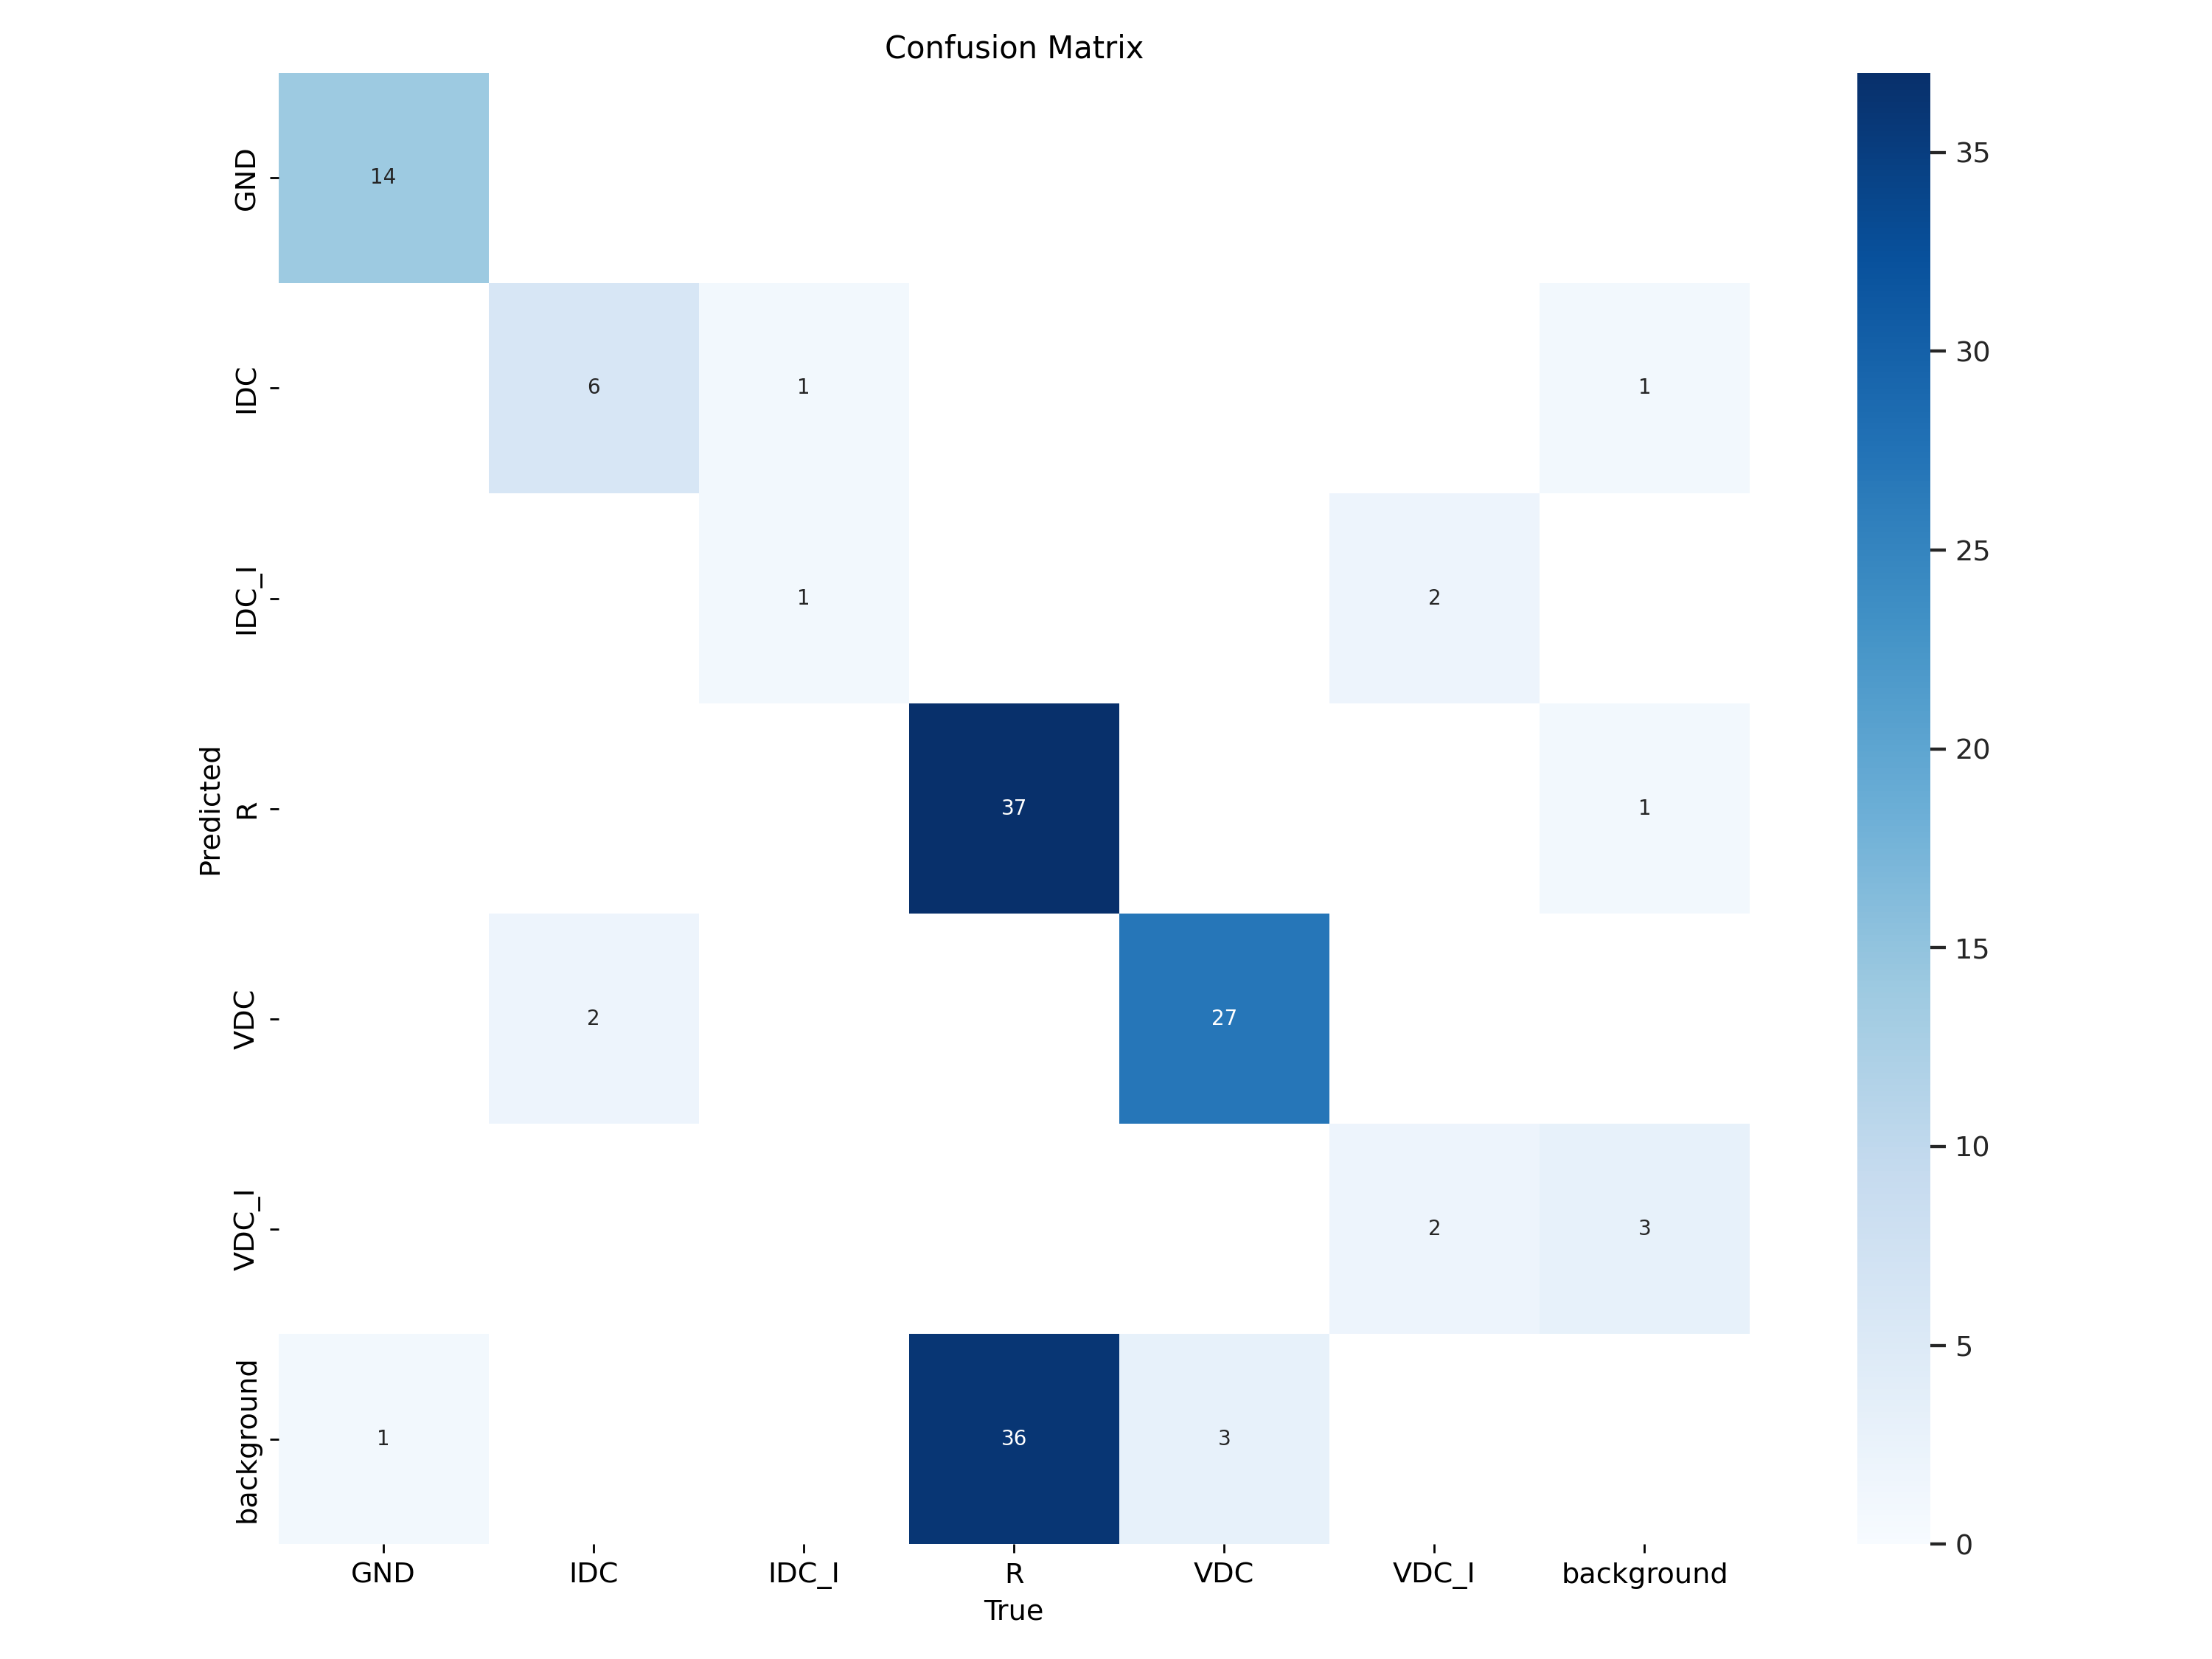

In [25]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=1000)

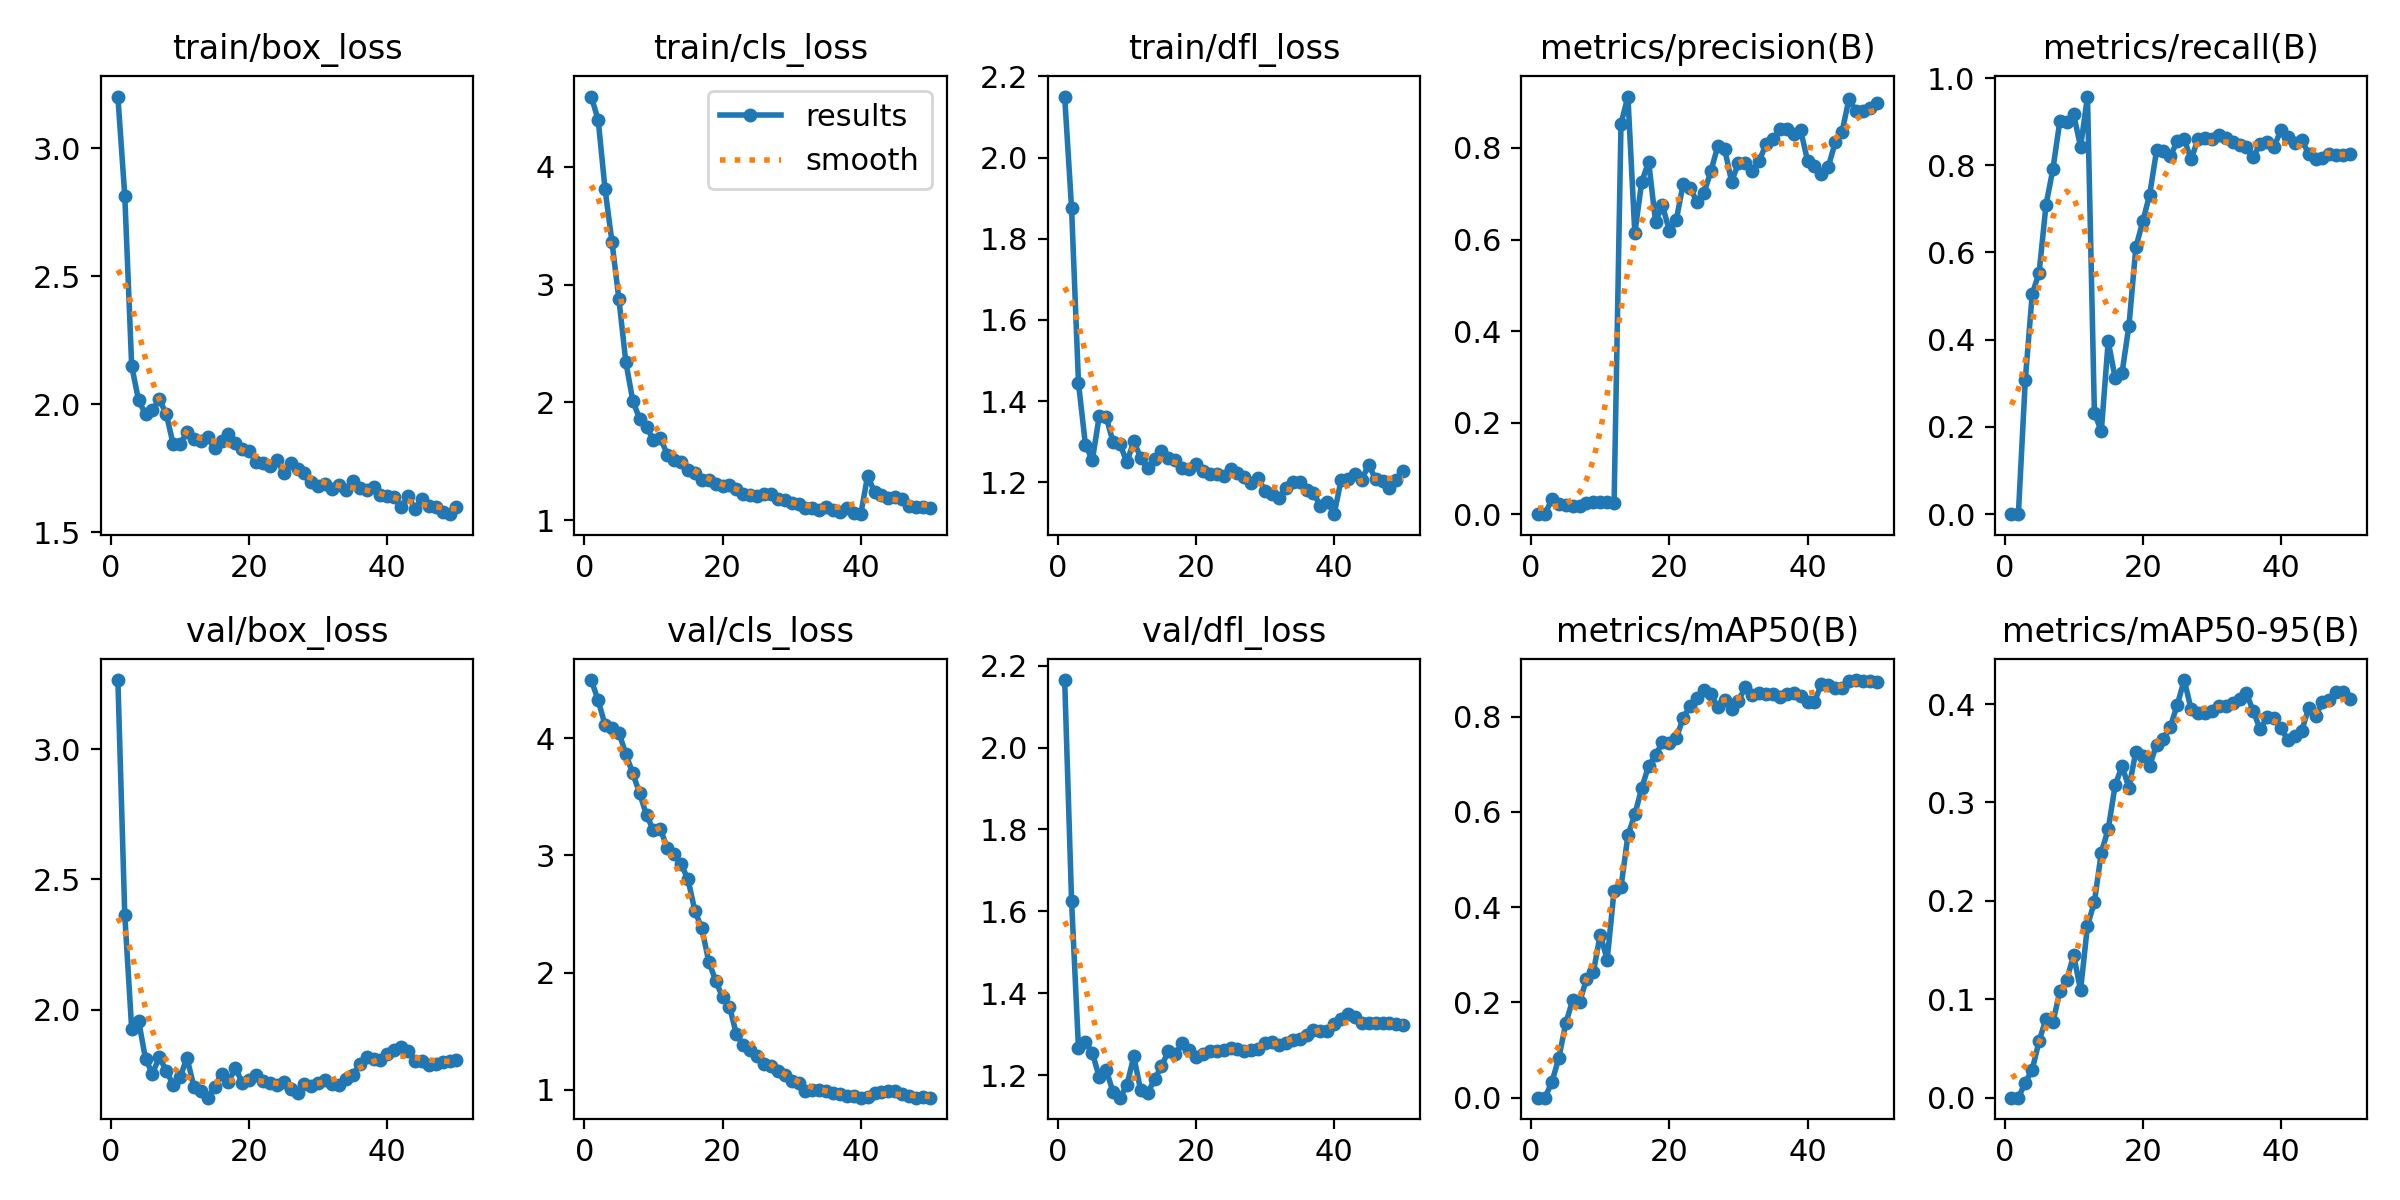

In [26]:
from IPython.display import Image

Image(filename=f'{HOME}/runs/detect/train/results.png', width=1000)

In [27]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

ds.classes

['GND', 'IDC', 'IDC_I', 'R', 'VDC', 'VDC_I']

In [28]:
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [29]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.39689358129952185
mAP 50 0.7897742155167897
mAP 75 0.35600874647904346


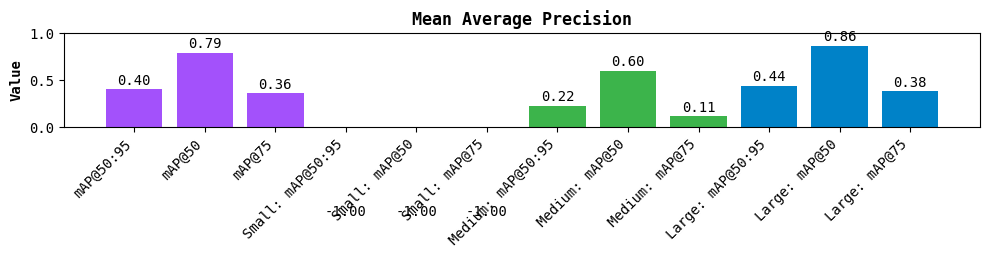

In [30]:
map.plot()

## Run inference with fine-tuned YOLOv12 model

In [31]:
import supervision as sv

model = YOLO(f'/{HOME}/runs/detect/train/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

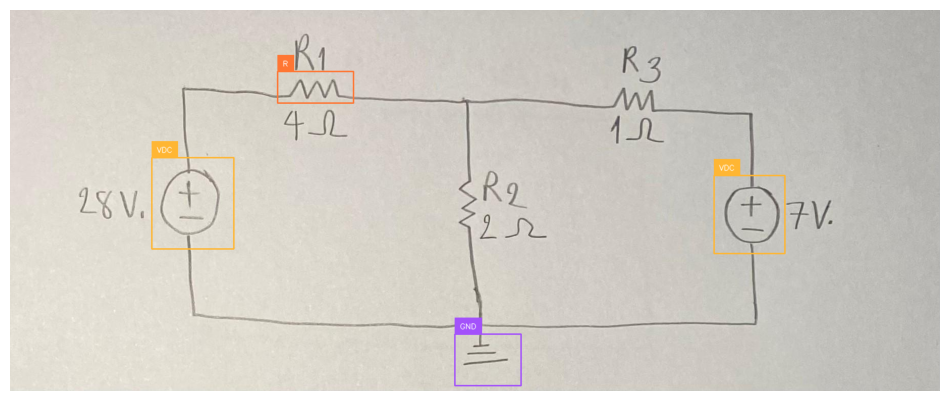

In [32]:
import random

i = random.randint(0, len(ds))

image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="G4Did6joLQEJ5npDriR9")
project = rf.workspace("caroline-rhh2u").project("-rznc2")
version = project.version(1)
dataset = version.download("yolov12")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 108.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 圖-1 in yolov12:: 100%|██████████| 245/245 [00:00<00:00, 7382.75it/s]
